In [3]:
# # Notebook 03 — Validação Final em Dados Reais (Filmes)

import pandas as pd
import numpy as np
import os
import zipfile
import gdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# ==============================================================================
# 1. DOWNLOAD E EXTRAÇÃO AUTOMÁTICA DOS DADOS REAIS (DRIVE)
# ==============================================================================
file_id = '1geGeE0m4WY8RF9iie45vzR4wRKNYoG2T'
url = f'https://drive.google.com/uc?id={file_id}'
output_zip = 'utlc_movies.zip'
extracted_folder = 'dados_reais'

if not os.path.exists(output_zip):
    print("Iniciando download do dataset real (.zip) do Google Drive...")
    gdown.download(url, output_zip, quiet=False)

if not os.path.exists(extracted_folder):
    print("Extraindo arquivos...")
    with zipfile.ZipFile(output_zip, 'r') as zip_ref:
        zip_ref.extractall(extracted_folder)
    print("Extração concluída!")

path_csv_real = os.path.join(extracted_folder, "utlc_movies.csv")


In [5]:
# ==============================================================================
# 2. CARREGAMENTO E MAPEAMENTO DE 3 CLASSES (DADOS REAIS)
# ==============================================================================
print("Carregando e tratando os dados reais (limitando a 100k para performance)...")
df_real_raw = pd.read_csv(path_csv_real, nrows=100000)

def converter_para_3_classes(rating):
    if rating >= 4:
        return 'Positiva'
    elif rating <= 2:
        return 'Negativa'
    else:
        return 'Neutra'

df_real_raw['sentimento'] = df_real_raw['rating'].apply(converter_para_3_classes)
df_real = df_real_raw[['review_text', 'sentimento']].dropna()
df_real.columns = ['texto', 'label']

print("\nDistribuição das classes nos dados reais (Movies):")
print(df_real['label'].value_counts())

Carregando e tratando os dados reais (limitando a 100k para performance)...

Distribuição das classes nos dados reais (Movies):
label
Positiva    70776
Neutra      19975
Negativa     9249
Name: count, dtype: int64


In [7]:
# ==============================================================================
# 3. PIPELINE DE TESTE (TREINO SINTÉTICO -> TESTE REAL)
# ==============================================================================
url_synthetic = "https://raw.githubusercontent.com/ROMAUSKI/tcc-analise-sentimento/main/dados/processado/synthetic_dataset.csv"

print("\nBaixando dados sintéticos do GitHub...")
df_sintetico = pd.read_csv(url_synthetic)

print("Treinando modelo com dados sintéticos...")
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

# Usando as colunas exatas do seu dataset sintético
X_train = vectorizer.fit_transform(df_sintetico['frase_limpa'])
y_train = df_sintetico['classe']

modelo = MultinomialNB()
modelo.fit(X_train, y_train)

print("Avaliando nos dados reais extraídos...")
# Aqui mantemos 'texto' e 'label' porque foi assim que estruturamos o df_real na Célula 2
X_test_real = vectorizer.transform(df_real['texto'])
y_test_real = df_real['label']

y_pred = modelo.predict(X_test_real)
print("✅ Predições concluídas com sucesso!")


Baixando dados sintéticos do GitHub...
Treinando modelo com dados sintéticos...
Avaliando nos dados reais extraídos...
✅ Predições concluídas com sucesso!


In [10]:
# ==============================================================================
# 4. EXIBIÇÃO DE RESULTADOS COM VISUAL MELHORADO E PERCENTUAL
# ==============================================================================
print("\n" + "="*75)
print("📊 RELATÓRIO DE DESEMPENHO DO MODELO (SINTÉTICO -> REAL)")
print("="*75)

# 1. Gera o relatório em dicionário
relatorio_dict = classification_report(y_test_real, y_pred, output_dict=True)

# 2. Retira a acurácia geral temporariamente para não bagunçar a tabela
acuracia_geral = relatorio_dict.pop('accuracy')

# 3. Transforma em DataFrame do Pandas
df_relatorio = pd.DataFrame(relatorio_dict).transpose()

# 4. Adiciona a linha de Acurácia manualmente no final para ficar alinhado
total_frases = df_relatorio.loc['macro avg', 'support']
df_relatorio.loc['Acurácia Geral'] = [np.nan, np.nan, acuracia_geral, total_frases]

# 5. Traduz as linhas e colunas
df_relatorio.rename(index={'macro avg': 'Média Macro', 'weighted avg': 'Média Ponderada'}, inplace=True)
df_relatorio.columns = ['Precisão', 'Recall', 'F1-Score', 'Quantidade']

# 6. Converte para Percentual (Multiplica por 100 e formata para xx,xx%)
colunas_metricas = ['Precisão', 'Recall', 'F1-Score']
for col in colunas_metricas:
    df_relatorio[col] = (df_relatorio[col] * 100).apply(
        lambda x: f"{x:.2f}%".replace('.', ',') if pd.notnull(x) else "-"
    )

# 7. Limpa a coluna Quantidade para mostrar números inteiros
df_relatorio['Quantidade'] = df_relatorio['Quantidade'].astype(int)

# Exibe a tabela bonitona no Colab
display(df_relatorio)

# ==============================================================================
# LEGENDA DIRETA PARA A BANCA
# ==============================================================================
print("\n" + "-"*75)
print("📌 O QUE SIGNIFICA CADA COLUNA:")
print("• Precisão:   Dos chutes que o modelo deu para essa classe, quantos ele acertou?")
print("• Recall:     De todos os reais dessa classe, quantos o modelo conseguiu achar?")
print("• F1-Score:   A nota de equilíbrio entre Precisão e Recall (de 0 a 100%).")
print("• Quantidade: Número real de frases dessa classe que o modelo teve que testar.")
print("• Acurácia:   Taxa geral de acertos somando todas as classes juntas.")
print("-" * 75)


📊 RELATÓRIO DE DESEMPENHO DO MODELO (SINTÉTICO -> REAL)


,Precisão,Recall,F1-Score,Quantidade
Negativa,"15,22%","60,50%","24,32%",9249
Neutra,"17,11%","16,92%","17,01%",19975
Positiva,"79,09%","48,58%","60,19%",70776
Média Macro,"37,14%","42,00%","33,84%",100000
Média Ponderada,"60,80%","43,36%","48,25%",100000
Acurácia Geral,-,-,"43,36%",100000



---------------------------------------------------------------------------
📌 O QUE SIGNIFICA CADA COLUNA:
• Precisão:   Dos chutes que o modelo deu para essa classe, quantos ele acertou?
• Recall:     De todos os reais dessa classe, quantos o modelo conseguiu achar?
• F1-Score:   A nota de equilíbrio entre Precisão e Recall (de 0 a 100%).
• Quantidade: Número real de frases dessa classe que o modelo teve que testar.
• Acurácia:   Taxa geral de acertos somando todas as classes juntas.
---------------------------------------------------------------------------



Gerando gráfico de desempenho...


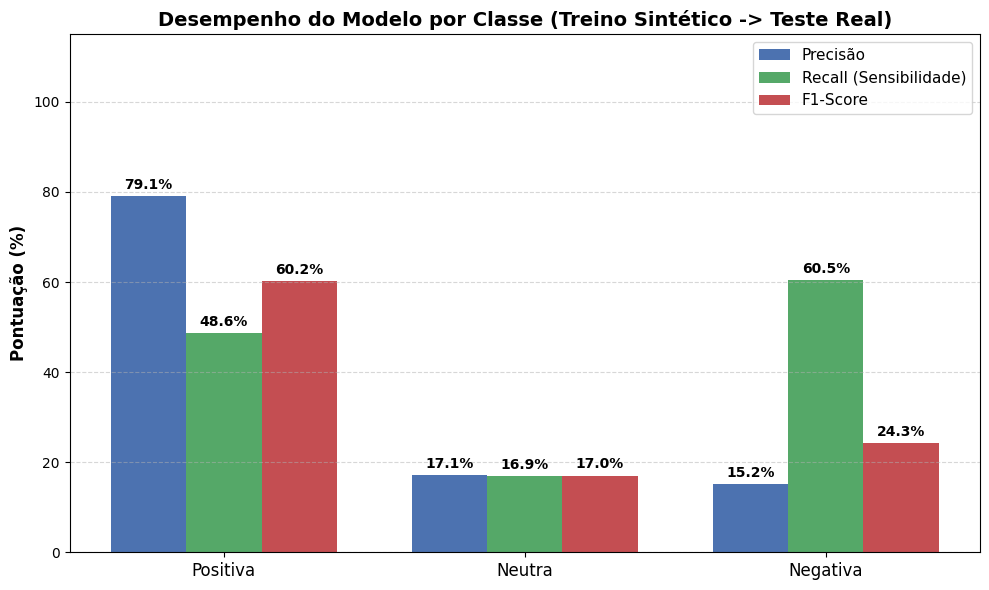

✅ Gráfico gerado com sucesso!


In [13]:
# ==============================================================================
# 5. VISUALIZAÇÃO GRÁFICA DAS MÉTRICAS
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

print("\nGerando gráfico de desempenho...")

# 1. Calculando as métricas de forma limpa apenas para o gráfico
precisions, recalls, f1s, _ = precision_recall_fscore_support(
    y_test_real, y_pred, labels=['Positiva', 'Neutra', 'Negativa']
)

# 2. Convertendo tudo para porcentagem (0 a 100)
precisions = precisions * 100
recalls = recalls * 100
f1s = f1s * 100

# 3. Configurações do eixo X (As 3 classes)
labels = ['Positiva', 'Neutra', 'Negativa']
x = np.arange(len(labels))
width = 0.25  # Largura de cada barrinha

# 4. Criando a figura do gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# 5. Desenhando as barras (com cores profissionais)
rects1 = ax.bar(x - width, precisions, width, label='Precisão', color='#4C72B0')
rects2 = ax.bar(x, recalls, width, label='Recall (Sensibilidade)', color='#55A868')
rects3 = ax.bar(x + width, f1s, width, label='F1-Score', color='#C44E52')

# 6. Customizando textos e eixos
ax.set_ylabel('Pontuação (%)', fontsize=12, fontweight='bold')
ax.set_title('Desempenho do Modelo por Classe (Treino Sintético -> Teste Real)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 115) # Espaço extra no topo para caber a legenda e os números
ax.legend(loc='upper right', fontsize=11)

# 7. Função para escrever as porcentagens em cima de cada barra
def colocar_valores(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

colocar_valores(rects1)
colocar_valores(rects2)
colocar_valores(rects3)

# 8. Renderizando o gráfico final
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("✅ Gráfico gerado com sucesso!")

In [15]:
# ==============================================================================
# 6. ANÁLISE QUALITATIVA DE ERROS (TEXTO COMPLETO PARA O ARTIGO)
# ==============================================================================
import pandas as pd

print("\n🔍 EXTRAINDO EXEMPLOS DE ERROS PARA A DISCUSSÃO (REALITY GAP)...\n")

# 1. Cria um DataFrame com os dados reais e as predições lado a lado
df_analise = pd.DataFrame({
    'Frase Original': df_real['texto'].reset_index(drop=True),
    'Sentimento Real': y_test_real.reset_index(drop=True),
    'Chute do Modelo': y_pred
})

# 2. Filtra apenas as discrepâncias (onde o modelo errou)
df_erros = df_analise[df_analise['Sentimento Real'] != df_analise['Chute do Modelo']]

# 3. Pega exemplos FATAIS (Era Negativa, modelo achou que era Positiva)
erros_fatais = df_erros[
    (df_erros['Sentimento Real'] == 'Negativa') &
    (df_erros['Chute do Modelo'] == 'Positiva')
]

# 4. Pega exemplos NEUTROS (Não entendeu a neutralidade)
erros_neutros = df_erros[
    (df_erros['Sentimento Real'] == 'Neutra') &
    (df_erros['Chute do Modelo'] != 'Neutra')
]

# ==========================================================================
# Função para imprimir bonito, sem cortar texto e fácil de copiar pro Word
# ==========================================================================
def imprimir_relatorio(df_amostra, titulo, icone):
    print(f"{icone} {titulo}")
    print("=" * 85)

    # Pega até 5 exemplos aleatórios
    amostra = df_amostra.sample(n=min(5, len(df_amostra)), random_state=42) # random_state fixa os mesmos exemplos sempre

    for i, (_, linha) in enumerate(amostra.iterrows(), 1):
        print(f"Exemplo {i}:")
        print(f"📝 TEXTO  : {linha['Frase Original']}")
        print(f"✅ REAL   : {linha['Sentimento Real']}")
        print(f"❌ PREDITO: {linha['Chute do Modelo']}")
        print("-" * 85)
    print("\n")

# 5. Executando a impressão
if not erros_fatais.empty:
    imprimir_relatorio(erros_fatais, "ERROS CRÍTICOS (Falsos Positivos)", "🚨")

if not erros_neutros.empty:
    imprimir_relatorio(erros_neutros, "CONFUSÃO COM A CLASSE NEUTRA", "🤷‍♂️")

print("💡 DICA PARA O TCC:")
print("Copie 2 ou 3 desses exemplos para uma tabela no seu artigo e explique na seção de Discussão")
print("como a ironia, gírias ou palavras de duplo sentido confundiram o modelo sintético.")


🔍 EXTRAINDO EXEMPLOS DE ERROS PARA A DISCUSSÃO (REALITY GAP)...

🚨 ERROS CRÍTICOS (Falsos Positivos)
Exemplo 1:
📝 TEXTO  : é um filme de baixo orçamento, mas muito bem sacado.
✅ REAL   : Negativa
❌ PREDITO: Positiva
-------------------------------------------------------------------------------------
Exemplo 2:
📝 TEXTO  : Exaustivo. Me senti desalmado até o fim.
✅ REAL   : Negativa
❌ PREDITO: Positiva
-------------------------------------------------------------------------------------
Exemplo 3:
📝 TEXTO  : A trilha musical do filme e o modo com que essa remete aos filmes antigos de horror com violinos desordenados e gritos de pavor é excelente! O trabalho com a criação de uma atmosfera de suspense, que algo está acontecendo de errado (o que me lembrou "A Bruxa de Blair" -talvez até pela temática-) foi muito bem feito. Porém, acho que a tensão é um pouco quebrada pelos gêmeos, que deixaram algumas cenas cômicas.
✅ REAL   : Negativa
❌ PREDITO: Positiva
---------------------------------